NB!!

(Level 3 task 3 below level 3 task 2)

NB!!

# Level 3 Task 2

**Import Libraries**

In [112]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

# Libraries for visualisation
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

**Load The Dataset**

In [113]:
# Load the dataset
titanic_df = pd.read_csv("titanic.csv")

**Process and Train The Data**

The following cell required extra research. I initially only worked out the age-median for missing values, but after researching, it was found that transforming the data and grouping the Class with Age would yield a lot more accurate model. Reason: Age distribution would also differ based on their class, thus, it would most likely give more accurate values for missing age data.

I also found that when making these trees, leaving out Data entries (Such as Tickets which could hold valuable patterns) should be avoided if possible. And to use it would be better than not. I was able to find appropriate examples on how Stacks Overflow.

In [114]:
# While reviewing the data, a lot of age values are missing.
# Age is an Important factor so cannot be dropped. Doing
# Research on how to fix this, it was learned we can replace
# The empty values with the median
# Of the age of the passengers. Age and Pclass were grouped to
# Then replace the missing values with the median of the age
# Of the passengers in the same class.
titanic_df["Age"] = titanic_df["Age"].fillna(
    titanic_df.groupby("Pclass")["Age"].transform("median"))


# Extract the ticket prefixes
titanic_df["TicketPrefix"] = titanic_df["Ticket"].apply(
    lambda x:x.split()[0] if not x.isdigit() else "NoPrefix")

# Map each prefix to its frequency count
prefix_counts = titanic_df[
    "TicketPrefix"].value_counts().to_dict()
titanic_df["TicketPrefixFreq"] = titanic_df[
    "TicketPrefix"].map(prefix_counts)


In [115]:

# Convert the categorical variables into numerical/boolean
# Values
titanic_df = pd.get_dummies(titanic_df, prefix="Sex",
                            columns=["Sex"])
titanic_df = pd.get_dummies(titanic_df, prefix="Embarked",
                            columns=["Embarked"])

# Determine the dependent and independent variables
X = titanic_df[['Pclass', 'Sex_male', 'Sex_female',
                'Age', 'SibSp', 'Parch', 'Fare',
                'Embarked_C', 'Embarked_Q',
                'Embarked_S', 'TicketPrefixFreq']]
y = titanic_df['Survived']


# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                y, test_size= 0.25, random_state=0)

# Split the training data into training and development sets
X_train, X_dev, y_train, y_dev = train_test_split(X_train,
y_train, test_size=0.25, random_state=42)

**Drop Unnecessary Colums**

In [116]:
# You can also drop whichever other columns you'd like here
# Cabin is dropped because it has a lot of missing values
titanic_df.drop("Cabin", axis=1, inplace=True)

# Drop original Ticket columns and TicketPrefix
# The Ticket prefix and its frequency has already been extracted
titanic_df.drop(columns=["Ticket", "TicketPrefix"], inplace=True)

**Train a model without Pruning**

Performance without pruning: 0.7604790419161677
At depth: 15
Final performance on test set: 0.8071748878923767


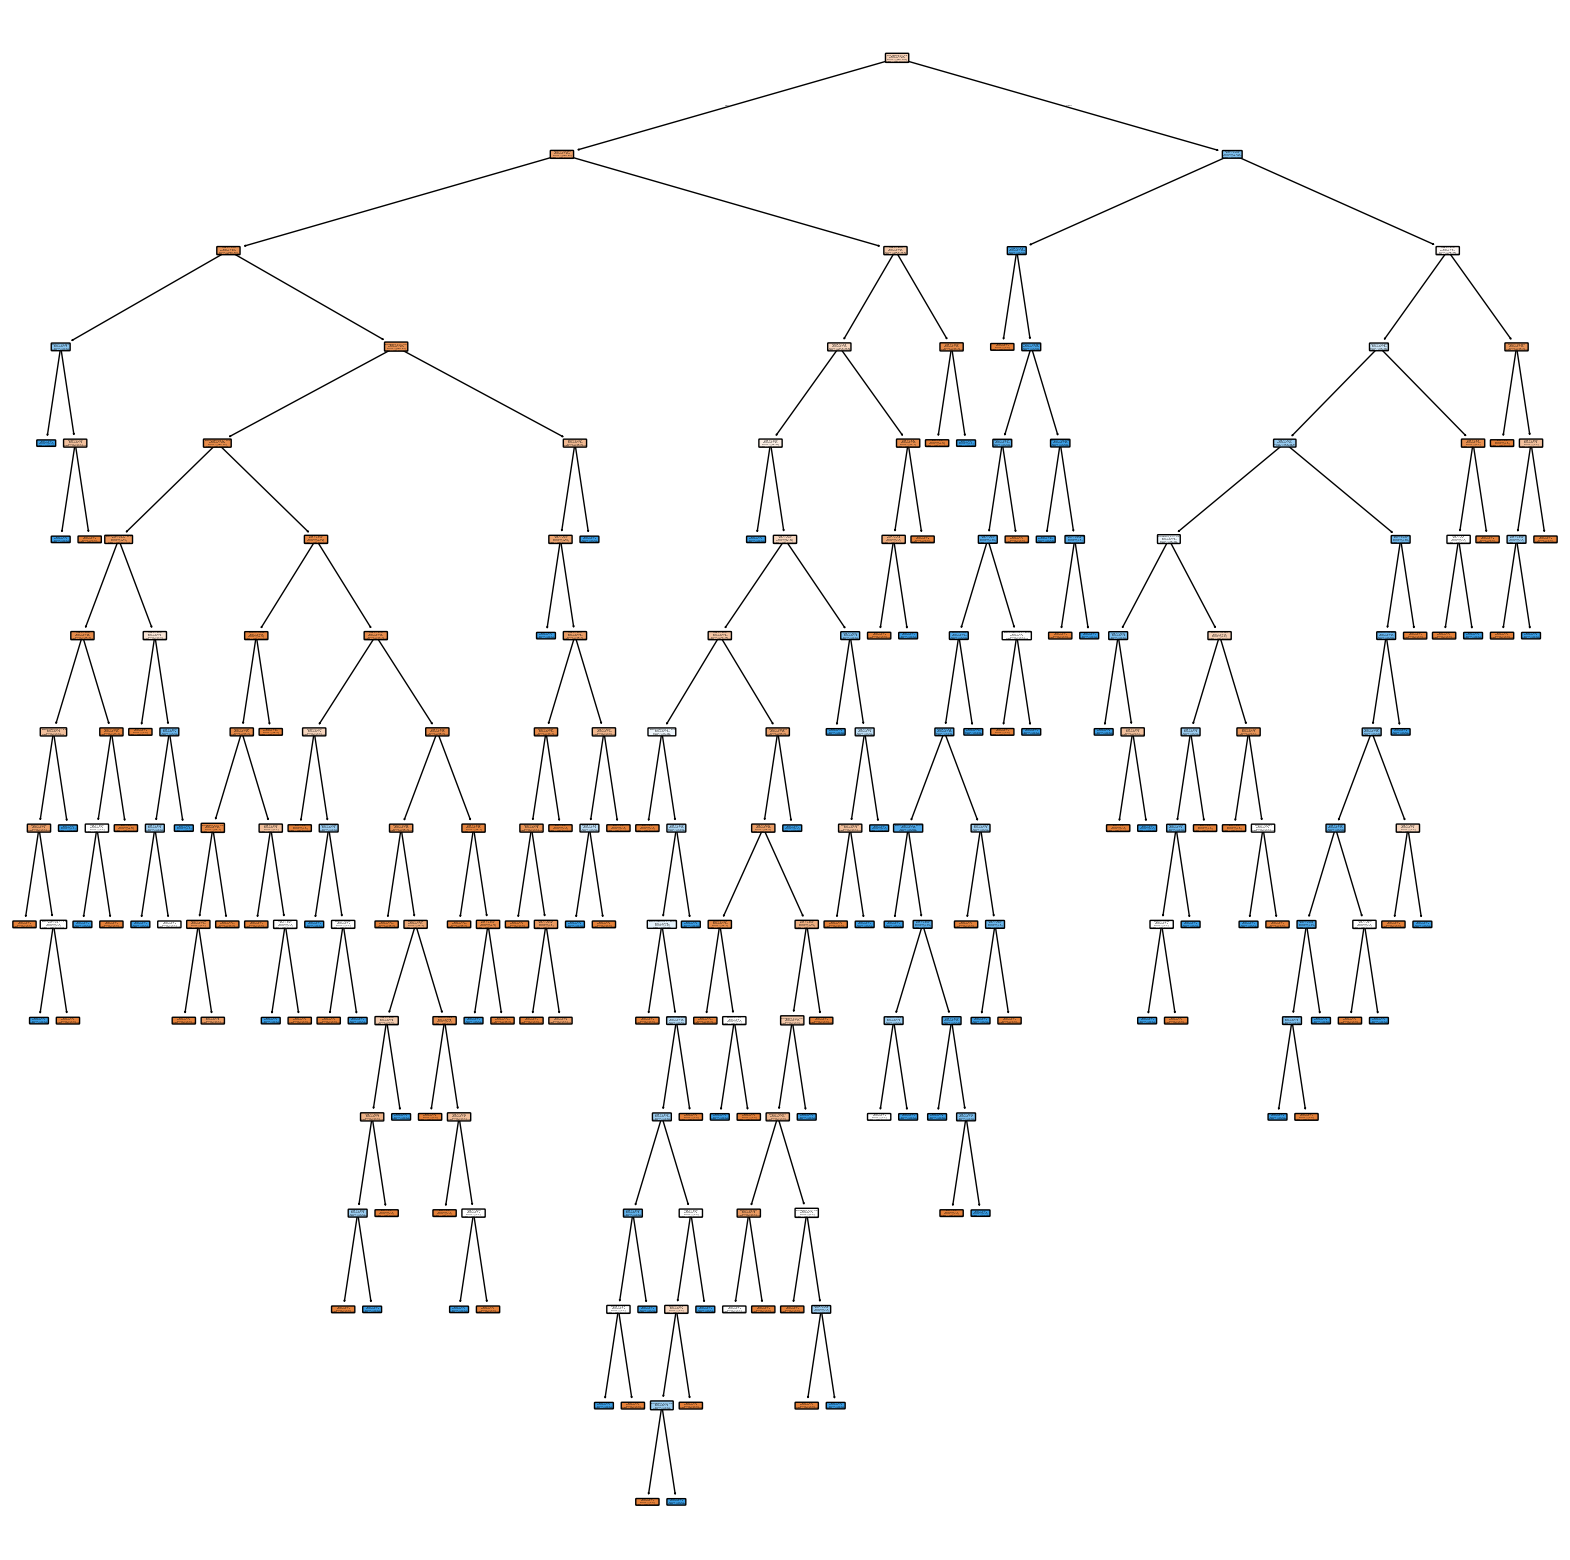

In [117]:
# Train a model without pruning the data
unpruned = DecisionTreeClassifier(max_depth=None, random_state=0)
unpruned.fit(X_train, y_train)
print("Performance without pruning:", unpruned.score(X_dev, y_dev))
print("At depth:", unpruned.tree_.max_depth)

# Print the final model on the test set using .score
print("Final performance on test set:", unpruned.score(X_test, y_test))

# Plot unpruned decision tree (Fig size had to be adjusted to 
# fit everything)
plt.figure(figsize=(20, 20))
plot_tree(unpruned, filled=True, feature_names=X.columns,
          class_names=['Not Survived', 'Survived'], rounded=True)
plt.show()

**Train a Model with Pruning**

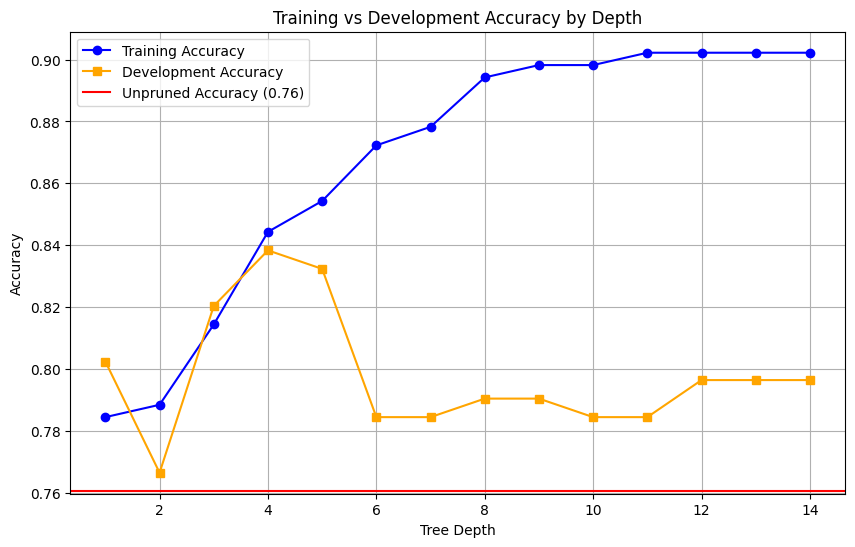

In [118]:
# Define a range of depths to test, as well as lists to store
# The training scores and development scores
pruned_depths = range(1, 15)
train_scores = []
dev_scores = []

# Loop through different depths to train prune the training data
# Also store the training and development scores
for depth in pruned_depths:
    pruned = DecisionTreeClassifier(max_depth=depth,
                min_samples_split=10, random_state=0)
    pruned.fit(X_train, y_train)

    train_scores.append(pruned.score(X_train, y_train))
    dev_scores.append(pruned.score(X_dev, y_dev))

# Get the unpruned model's accuracy for visual comparison on
# the plotted graph
unpruned_dev_acc = unpruned.score(X_dev, y_dev)


# Using the training and development accuracy, a graph can be
# plotted to show the model's at different depths
plt.figure(figsize=(10, 6))
plt.plot(pruned_depths, train_scores, marker='o', 
        label='Training Accuracy', color='blue')

plt.plot(pruned_depths, dev_scores, marker='s',
        label='Development Accuracy', color='orange')

# Add the unpruned model accuracy as a horizontal line
plt.axhline(y=unpruned_dev_acc, color='red', 
            label=f'Unpruned Accuracy ({unpruned_dev_acc:.2f})')

# Plot information(labels, title, legend, grid)
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Development Accuracy by Depth')
plt.legend()
plt.grid(True)
plt.show()


*Comments on Graph:*

Training accuracy: As seen, the blue line steadily increases as the tree dept increases.  This is most likely because deeper tree depths fit the training data better, which leads to a higher accuracy. However, at 14 depth accuracy is really high which could indicate overfitting

Development accuracy: The green line initially creases, and reaches its highest peak at 4-5 depth, then leads to a sudden fall/decline. This could be an indication that the deeper trees are being overfitted.

Thus, the best tree depth is around 4-5, since deeper trees might not improve the accuracy of the trees and might cause overfitting.

**Now fit the best tree**

In [119]:
# Find the best tree depth
best_tree_depth = pruned_depths[np.argmax(dev_scores)]
print("Best tree depth found:", best_tree_depth)

# Train the best tree using the training data
best_tree = DecisionTreeClassifier(max_depth=best_tree_depth,
                        min_samples_split=10, random_state=0)
best_tree.fit(X_train, y_train)
print("Final performance of best tree on test set:", 
      best_tree.score(X_test, y_test))

Best tree depth found: 4
Final performance of best tree on test set: 0.820627802690583


**Best tree**

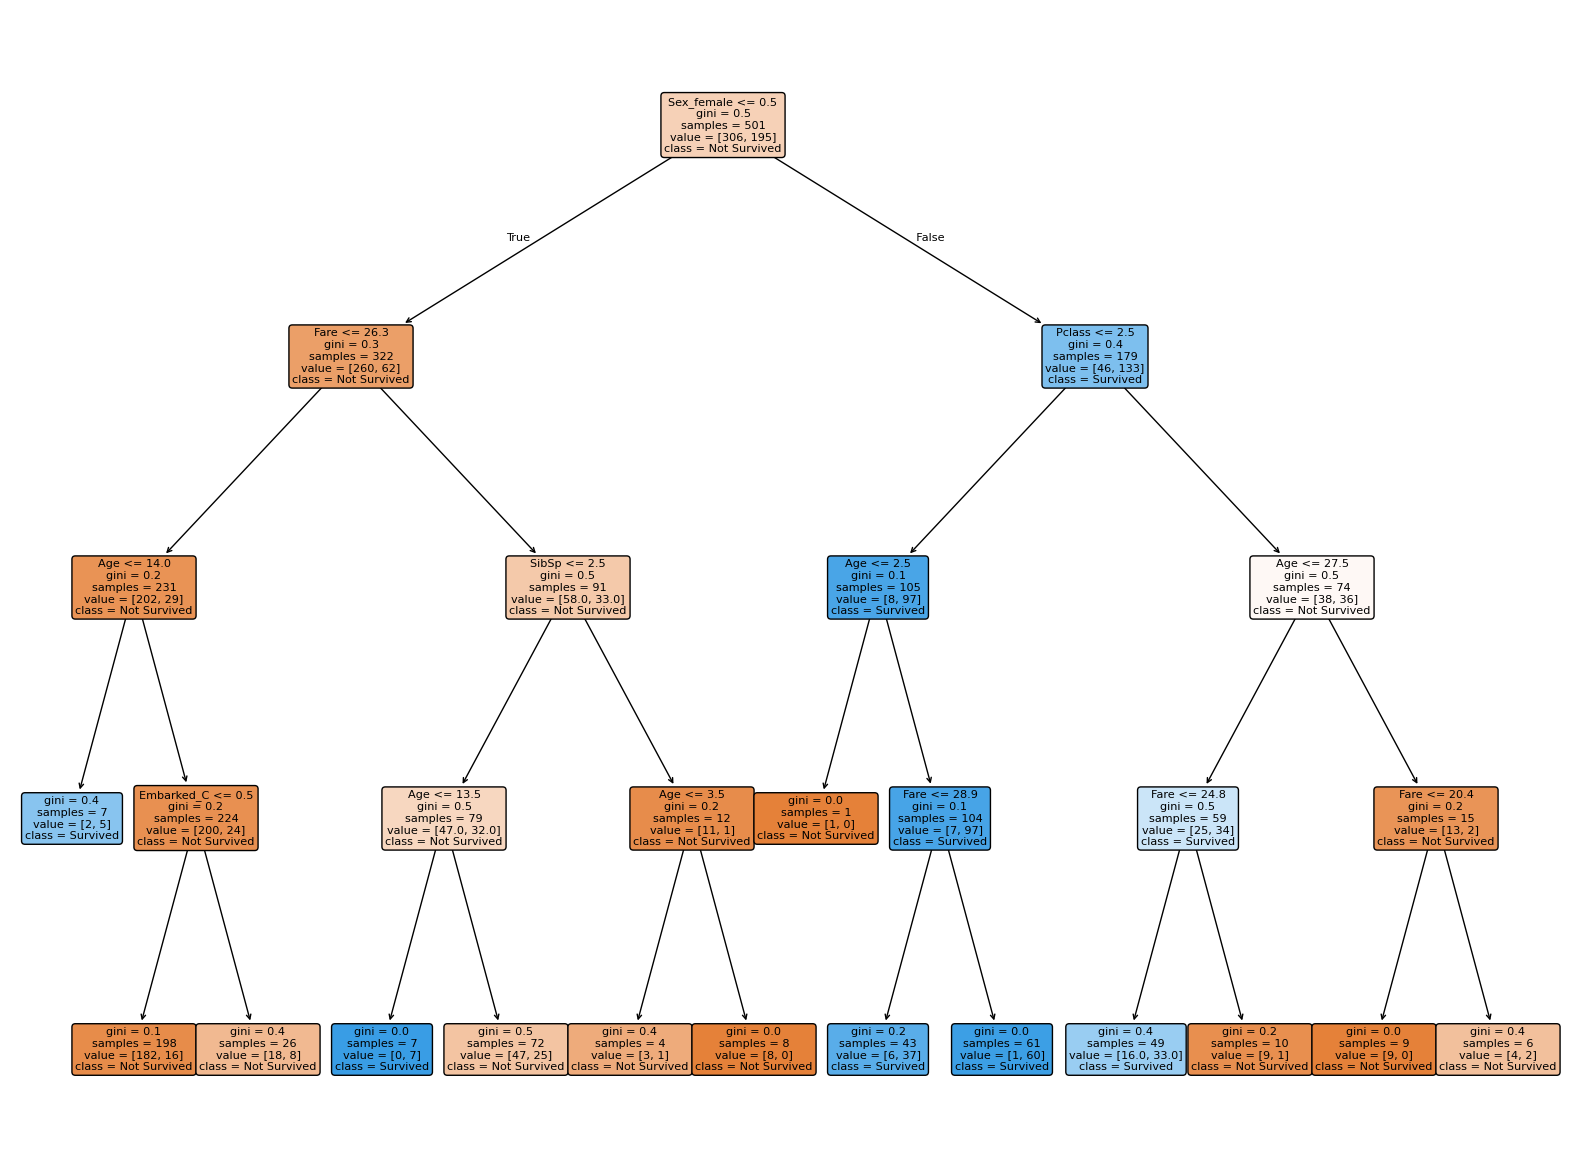

In [120]:
# Plot the best tree
plt.figure(figsize=(20, 15))
plot_tree(best_tree, filled=True, feature_names=X.columns, 
          class_names=['Not Survived', 'Survived'], 
          rounded=True, precision=True)
plt.show()


**Evaluating the model**

In [121]:
# Predictions using the best pruned tree
y_pred = best_tree.predict(X_test)

# Evaluate model performance using confusion 
# Matrix and classification report
# Classification report shows precision, recall, 
# f1-score and support, which
# Is a faster way rather than printing out them individually
print("Confusion Matrix:\n", 
      confusion_matrix(y_test, y_pred))
print("Classification Report:\n", 
      classification_report(y_test, y_pred))


Confusion Matrix:
 [[126  13]
 [ 27  57]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       139
           1       0.81      0.68      0.74        84

    accuracy                           0.82       223
   macro avg       0.82      0.79      0.80       223
weighted avg       0.82      0.82      0.82       223



**Interpretation**

When viewing the confusion matrix:

The model predicted 126 True Negatives(Deceased) correctly, but incorrectly predicted 13 False negatives. When in fact those 13 did not survive. The model predicted correctly 57 True Positives (Survivors), but incorrectly predicted 27 False Negatives, when in fact those 27 did survive. 

This Model has an overall accuracy of 0.82, but recall of 0.68 which means it missed some of the survivors. 

Final findings: The model has a good accuracy of 82%, however if the purpose of the model is to identify all survivors further improvements are needed.

**Additional comments**

As the comments suggested, the best tree fit was found around the 4-5 depth. Using DecisionTreeClassifier the 4th depth tree was found to be a best fit. Which is good!

# LEVEL 3 TASK 3

**Import appropriate libraries**

In [122]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score



**Train Bagged trees**

In [123]:
# Using the example provided (Random_forest.ipynb), it was
# Shown how To use the BaggingClassifier to create an ensemble
# Of decision trees The base model is a decision tree with max depth=5
base = DecisionTreeClassifier(max_depth= 5)
bagged_tree = BaggingClassifier(estimator= base,
                                n_estimators=50, random_state=0)

# For the base model and bagged tree, then calculate the accuracy
base.fit(X_train, y_train)
bagged_tree.fit(X_train, y_train)
bagged_tree_acc = accuracy_score(y_test, bagged_tree.predict(X_test))

# Print the accuracy of the base model and the ensemble to ensure it
# was calculated correctly
print("Base Accuracy:",base.score(X_test, y_test))
print("Bagged Tree Accuracy:",bagged_tree_acc)

Base Accuracy: 0.8026905829596412
Bagged Tree Accuracy: 0.8161434977578476


**Train a Boosted tree using AdaBoost**

In [124]:

# Using AdaBoost we can create a boosted tree ensemble, and then
# calculate the accuracy of the boosted tree model
boosted_tree = AdaBoostClassifier(n_estimators=100, random_state=0)
boosted_tree.fit(X_train, y_train)
boosted_acc = accuracy_score(y_test, boosted_tree.predict(X_test))

# Print the accuracy of the boosted model to ensure it was calculated
# correctly
print("Boosted Trees' Accuracy:", boosted_acc)


Boosted Trees' Accuracy: 0.8071748878923767


**Train a random forest**

In [ ]:

# Use random forest classifier to create a random forest ensemble, 
# fit it, and calculate the accuracy of the model
random_forest_tree = RandomForestClassifier(n_estimators=100, 
                                       max_depth=10, random_state=0)
random_forest_tree.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, random_forest_tree.predict(X_test))

# Feature the importance from the random forest model
feature_importances = random_forest_tree.feature_importances_
most_important_feature = X.columns[np.argmax(feature_importances)]

# Tune a n_estimators and max_depth for the best Random Forest tree
# Model using a grid search, and storing the best model's parameters
# and accuracy
best_n, best_depth, best_acc = 0, 0, 0
for n in [50, 100, 150]:
    for depth in [5, 10, 15]:
        model = RandomForestClassifier(n_estimators=n,
                                        max_depth=depth, random_state=0)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        if acc > best_acc:
            best_n, best_depth, best_acc = n, depth, acc


# Print the accuracy of the random forest model, the most important 
# Feature, and the best model
print("Random Forest Accuracy:", rf_acc)
print("Most Important Feature in Random Forest:", most_important_feature)
print(f"""Best Random Forest Model: 
      n_estimators = {best_n}
      max_depth = {best_depth} 
      accuracy = {best_acc}""")

# Also show the ranking and index of the feature importance, to show which 
# Features are most important
feature_imp = pd.Series(feature_importances, 
                        index=X_train.columns).sort_values(ascending=False)
print("\nFeature Importance Ranking:")
print(feature_imp)


Random Forest Accuracy: 0.8295964125560538
Most Important Feature in Random Forest: Fare
Best Random Forest Model: 
      n_estimators = 50
      max_depth = 15 
      accuracy = 0.8385650224215246

Feature Importance Ranking:
Fare                0.226599
Age                 0.201388
Sex_female          0.166568
Sex_male            0.127849
Pclass              0.088252
SibSp               0.050954
TicketPrefixFreq    0.048120
Parch               0.042917
Embarked_C          0.020665
Embarked_S          0.016218
Embarked_Q          0.010471
dtype: float64


# Summary

**Report all the results**

In [126]:
# Neatly summarise all the results in a report, which will improve 
# The readability and make it easier to inspect and understand the results
print(f"""Report on accuracy of models:
      
Bagged Trees Accuracy: {bagged_tree_acc}
Random Forest Accuracy: {rf_acc}
Boosted Trees Accuracy: {boosted_acc}


Most Important Feature in Random Forest: {most_important_feature}


Best Random Forest Model: 
n_estimators = {best_n}
max_depth = {best_depth}
accuracy = {best_acc}""")



Report on accuracy of models:
      
Bagged Trees Accuracy: 0.8161434977578476
Random Forest Accuracy: 0.8295964125560538
Boosted Trees Accuracy: 0.8071748878923767


Most Important Feature in Random Forest: Fare


Best Random Forest Model: 
n_estimators = 50
max_depth = 15
accuracy = 0.8385650224215246


**Comments:**

As seen in the report above, the random Forest had the highest accuracy, with the best random forest model having an accuracy of 0.839 (83.86%). It was also found that the most important feature that determined the survival of passengers were based on the Fare.

When considering fare, which most likely was the price of their ticket (For this example let's say first class, second class, etc), would have played a role in who were prioritised in getting safety boats 

According to the official Titanic inquiry and investigation, There were 87 first class passengers, of whom 36 were saved, 253 second class passengers of whom 48 were saves, and then 717 third class passengers of whom 133 were saved. Of first class 41.38% were saved, 18.97% of second class, and 18.55% of third class (British Wreck Commissioner's Inquiry, 1912).

This shows that first class passengers were prioritised and thus had a higher chance of surviving. Showing that Fare was indeed an important factor when it came to who survived and who did not.

References:

British Wreck Commissioner's Inquiry (1912). Report on the Loss of the Titanic (S.S.). London: His Majesty’s Stationery Office. Available at: https://www.titanicinquiry.org (Accessed: [insert date]).